In [1]:
import os # sirve para interactuar con el sistema operativo
import cv2 # biblioteca para procesamiento de imágenes
import numpy as np # biblioteca para operaciones numéricas
from skimage.feature import hog # para extracción de características HOG
from sklearn.model_selection import train_test_split  # para dividir el conjunto de datos
from sklearn.svm import SVC # para el clasificador SVM
from sklearn.metrics import accuracy_score, classification_report # para evaluar el modelo
import matplotlib.pyplot as plt # para visualización

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression



In [2]:
VAL_PATH = 'DATASET-CLASE/DATASET/val'
TEST_PATH = 'DATASET-CLASE/DATASET/test'
TRAIN_PATH = 'DATASET-CLASE/DATASET/Train'

In [3]:
def procesar(DATASET_PATH):
    X = []
    y = []

    for label in os.listdir(DATASET_PATH):
        subcarpeta = os.path.join(DATASET_PATH, label)

        if not os.path.isdir(subcarpeta):
            continue

        for img_name in os.listdir(subcarpeta):
            img_path = os.path.join(subcarpeta, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                continue

            img = cv2.resize(img, (128, 128))

            features = hog(
                img,
                orientations=9,
                pixels_per_cell=(16, 16),
                cells_per_block=(2, 2)
            )

            X.append(features)
            y.append(label)

    return np.array(X), np.array(y)


In [4]:
X_train, y_train = procesar(TRAIN_PATH)
X_val, y_val = procesar(VAL_PATH)
X_test, y_test = procesar(TEST_PATH)
print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (112, 1764)
Val: (32, 1764)
Test: (16, 1764)


In [5]:
models = {
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=3),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "NaiveBayes": GaussianNB(),
    "LogisticRegression": LogisticRegression(max_iter=300)
}

In [6]:
resultados = {}

for nombre, modelo in models.items():

    print("\n======================")
    print("Modelo:", nombre)

    modelo.fit(X_train, y_train)

    val_pred = modelo.predict(X_val)
    acc_val = accuracy_score(y_val, val_pred)

    test_pred = modelo.predict(X_test)
    acc_test = accuracy_score(y_test, test_pred)

    print("Accuracy VAL:", acc_val)
    print("Accuracy TEST:", acc_test)

    resultados[nombre] = modelo


Modelo: SVM
Accuracy VAL: 0.90625
Accuracy TEST: 0.875

Modelo: KNN
Accuracy VAL: 0.90625
Accuracy TEST: 0.875

Modelo: RandomForest
Accuracy VAL: 0.90625
Accuracy TEST: 0.9375

Modelo: NaiveBayes
Accuracy VAL: 0.8125
Accuracy TEST: 0.75

Modelo: LogisticRegression
Accuracy VAL: 0.9375
Accuracy TEST: 0.9375


In [7]:
mejor_modelo = max(
    resultados,
    key=lambda k: accuracy_score(y_test, resultados[k].predict(X_test))
)

print("\n🏆 Mejor modelo:", mejor_modelo)

final_model = resultados[mejor_modelo]

y_pred = final_model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


🏆 Mejor modelo: RandomForest

Classification Report:

              precision    recall  f1-score   support

    AAlegria       1.00      1.00      1.00         1
       ALara       0.50      1.00      0.67         1
      ASaula       1.00      1.00      1.00         1
    BPepinos       1.00      1.00      1.00         1
  CCalapucha       1.00      1.00      1.00         1
     EChuico       1.00      1.00      1.00         1
   EZambrano       1.00      1.00      1.00         1
    FJimenez       1.00      1.00      1.00         1
   HQuintero       1.00      1.00      1.00         1
     JFranco       1.00      1.00      1.00         1
     JGuerra       1.00      1.00      1.00         1
    JJimenez       0.00      0.00      0.00         1
     JTorres       1.00      1.00      1.00         1
     MMolina       1.00      1.00      1.00         1
      PTapia       1.00      1.00      1.00         1
 RPuruncajas       1.00      1.00      1.00         1

    accuracy             

c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\jenni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [8]:
def predecir_persona(ruta, model):

    img = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (128,128))

    features = hog(
        img,
        orientations=9,
        pixels_per_cell=(16,16),
        cells_per_block=(2,2)
    )

    features = features.reshape(1,-1)

    return model.predict(features)[0]

👤 Predicción: JTorres


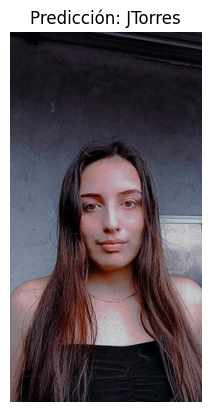

In [9]:
ruta_imagen = "image.png"

persona = predecir_persona(ruta_imagen, final_model)

print("👤 Predicción:", persona)

img = cv2.imread(ruta_imagen)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Predicción: {persona}")
plt.axis("off")
plt.show()